In [1]:
"""
Airline Passengers 시각화 스크립트
- 데이터: seaborn 내장 'flights' (= 고전 AirPassengers, 1949-1960, 144개월)
- 목적: 추세(trend) + 계절성(seasonality)의 시각적 탐색(EDA)
- 의존성: seaborn, matplotlib, pandas
"""
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

In [2]:
# ── 1. 데이터 로드 및 시간축 파생 ───────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
flights = sns.load_dataset("flights")            # columns: year, month, passengers

month_map = {m: i for i, m in enumerate(MONTHS, start=1)}
flights["month_num"] = flights["month"].astype(str).str[:3].map(month_map)
flights["date"] = pd.to_datetime(
    dict(year=flights["year"], month=flights["month_num"], day=1)
)

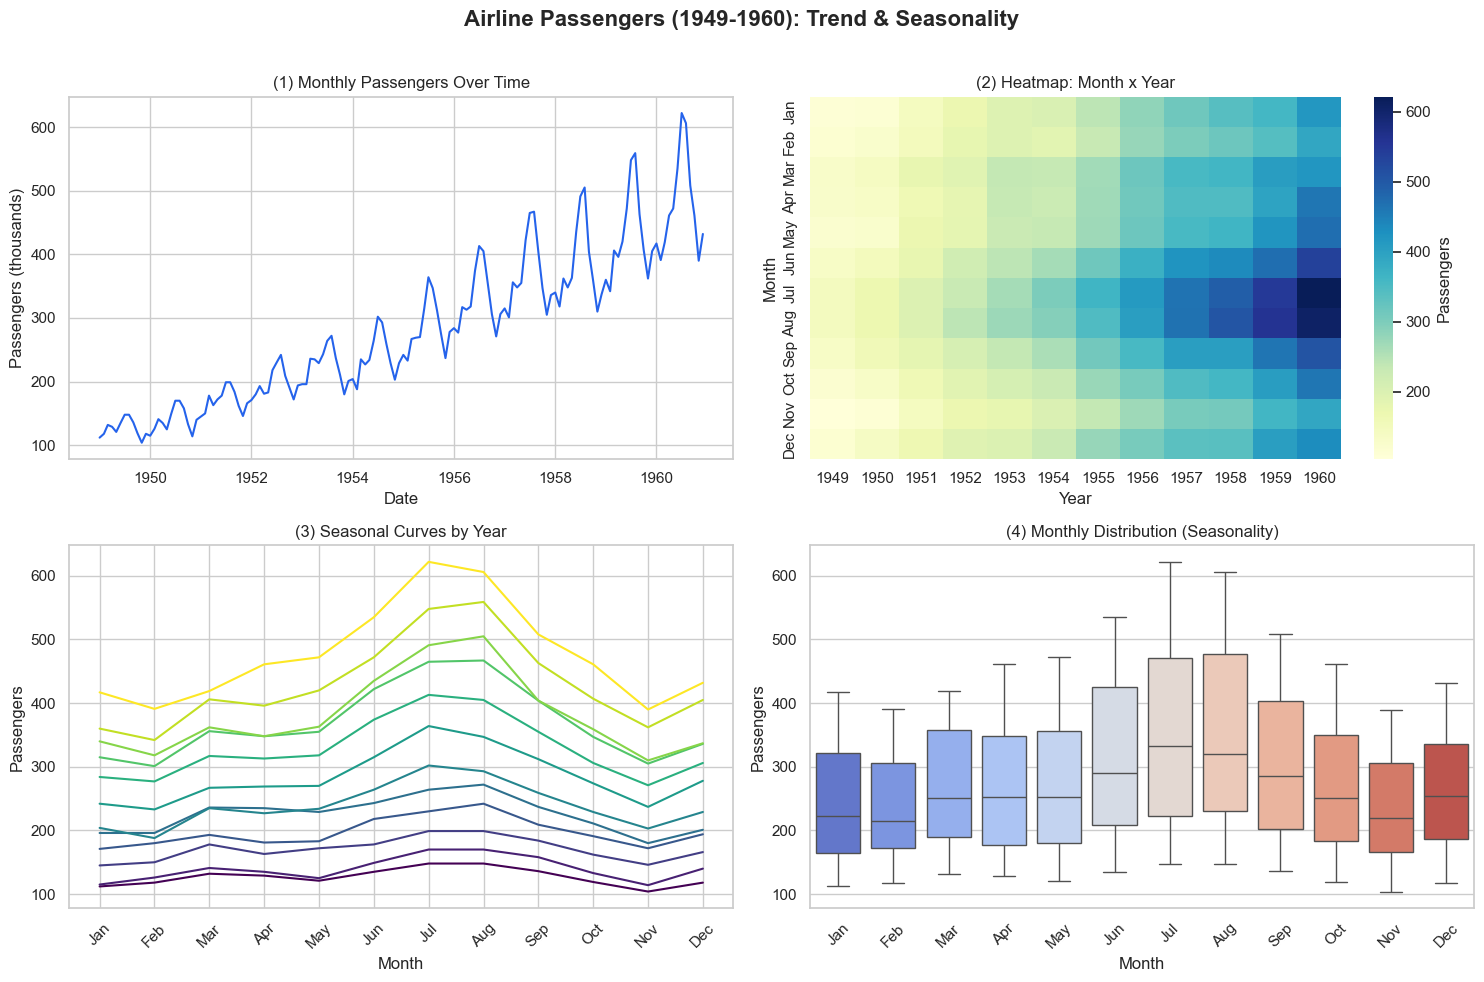

In [ ]:
# ── 2. 2x2 종합 시각화 ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Airline Passengers (1949-1960): Trend & Seasonality",
             fontsize=16, fontweight="bold")

# (1) 전체 시계열 — 우상향 추세 + 시간이 갈수록 커지는 계절 진폭(곱셈형 계절성)
sns.lineplot(data=flights, x="date", y="passengers", ax=axes[0, 0], color="#2563eb")
axes[0, 0].set_title("(1) Monthly Passengers Over Time")
axes[0, 0].set(xlabel="Date", ylabel="Passengers (thousands)")

# (2) 히트맵 (month x year) — 세로=계절성, 가로=추세 동시 관찰
pivot = (flights.pivot(index="month", columns="year", values="passengers")
                .reindex(MONTHS))
sns.heatmap(pivot, cmap="YlGnBu", ax=axes[0, 1], cbar_kws={"label": "Passengers"})
axes[0, 1].set_title("(2) Heatmap: Month x Year")
axes[0, 1].set(xlabel="Year", ylabel="Month")

# (3) 계절 곡선 — 월별 패턴을 연도별로 중첩(연도가 올라갈수록 위로 평행이동)
sns.lineplot(data=flights, x="month", y="passengers", hue="year",
             palette="viridis", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("(3) Seasonal Curves by Year")
axes[1, 0].set(xlabel="Month", ylabel="Passengers")
axes[1, 0].tick_params(axis="x", rotation=45)

# (4) 월별 분포 — 여름(Jul-Aug) peak로 계절성 집계 확인
sns.boxplot(data=flights, x="month", y="passengers", hue="month",
            palette="coolwarm", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("(4) Monthly Distribution (Seasonality)")
axes[1, 1].set(xlabel="Month", ylabel="Passengers")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 시각화 결과 해석

(1) Monthly Passengers Over Time — 추세 + 결합방식 진단

- 추세: 112 → 약 600으로 12년간 단조 증가. 전반적으로 우상향하는 강한 양(+)의 추세가 존재한다.
    → **비정상성(non-stationary in mean) 확정**.
- 계절성: 규칙적인 톱니형 진동이 매년 반복 → 연 1회 주기(annual cycle)의 계절성 존재.
- 핵심 진단 — 결합 방식: 진동의 진폭이 수준(level)에 비례해 커진다. 초기(1949)의 봉우리-골 폭은 작고, 후기(1960)는 크게 벌어진다.
    → 승법형(multiplicative) 계절성 및 분산이 평균과 함께 증가(heteroscedasticity).
- 함의: 모델링 시 log 변환으로 분산을 안정화하면 승법 구조가 가법 구조로 선형화된다.

(2) Heatmap (Month × Year) — 추세·계절성 직교 분해

- 가로축(연도) 방향: 왼쪽(1949, 연노랑) → 오른쪽(1960, 진남색)으로 일관되게 짙어짐. 이는 월과 무관하게 성립
    → 추세가 **계절성과 독립적으로 작동**함을 시각적으로 증명.
- 세로축(월) 방향: 모든 연도 열에서 Jul–Aug 행이 가장 짙다. 즉 여름 성수기 패턴이 12년 내내 위치를 바꾸지 않음.
- 전역 최대: 우하단(1960년 여름) 셀 = 최댓값. 추세와 계절 peak가 곱해진 지점.
- 함의: 히트맵은 추세(가로)와 계절성(세로)을 2차원으로 분리해 보여주는 분해(decomposition)의 시각적 등가물

(3) Seasonal Curves by Year — 계절 형태의 안정성

- 공통 형태: 모든 연도 곡선이 동일한 윤곽 — 봄 완만 상승 → Jul–Aug 정점 → 가을 하강 → Nov 저점 → 연말 소폭 반등.
- 수직 적층: 곡선들이 연도순으로 위로 평행 이동(추세). 단, 곡선 간 간격이 peak(여름)에서 더 크게 벌어짐 → (1)과 동일하게 승법 구조 재확인.
- 함의: 계절 패턴의 **형태(shape)는 시간 불변(time-invariant)**이고 규모(scale)만 추세에 따라 확대된다.
    - 이는 안정적 계절성(stable seasonality) 가정을 정당화하여 **SARIMA·Holt-Winters 같은 모델의 적용 근거**가 된다.

(4) Monthly Distribution — 계절성의 집계 통계

- 중앙값 곡선: Jan→Jul/Aug 상승 후 하강하는 ∩자형 → 여름 peak를 집계 수준에서 재확인.
- 산포(IQR/박스 높이): Jul–Aug 박스가 가장 크다. 이는 단지 평균이 높은 게 아니라, 승법성 때문에 후기 연도의 여름값이 극단적으로 커져 peak 월의 분산이 가장 크다는 뜻.
- 저점·저분산: Nov가 중앙값·산포 모두 최소권. 비수기이자 변동도 작다.
- 함의: 월을 범주로 묶으면 연도(추세) 정보가 박스 내부의 산포로 흡수된다. 따라서 박스 높이는 "그 달이 추세에 얼마나 민감한가"의 대리지표가 된다.

### Airline Passengers로 무엇을 알 수 있는가?
- "1950년대 민간 항공의 구조적 성장과 여행 계절성."
    - 추세 = 전후 상업 항공 산업의 구조적 성장(가처분소득·항공 인프라 확대로 12년간 약 5배 증가).
    - 여름 peak = 휴가철 여행 수요라는 사회적 계절 리듬. Jul–Aug 집중은 북반구 휴가 패턴과 정합.
- (결론) 즉 데이터는 "**성장하는 시장 위에 반복되는 행동 주기가 얹힌다**"는 현실 현상을 정량적으로 드러낸다.